In [90]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [91]:
base_path = r"C:\kdt_0900_pjh\machine_learning\resource\datasets"
file_name = r"telecom_customer.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 텔레콤 고객 이탈 데이터셋
[텔레콤 고객 이탈 데이터셋](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## 텔레콤 고객 이탈 데이터셋 컬럼
| 컬럼명 | 설명 |
| :--- | :--- |
| customerID | 고객 고유 식별자 |
| gender | 성별 |
| SeniorCitizen | 고령자 여부 (65세 이상) |
| Partner | 배우자 유무 |
| Dependents | 부양가족 유무 |
| tenure | 서비스 가입 기간 (개월 수) |
| PhoneService | 전화 서비스 가입 여부 |
| MultipleLines | 다중 회선 사용 여부 |
| InternetService | 인터넷 서비스 제공 방식 |
| OnlineSecurity | 온라인 보안 서비스 이용 여부 |
| OnlineBackup | 온라인 백업 서비스 이용 여부 |
| DeviceProtection | 기기 보호 옵션 이용 여부 |
| TechSupport | 전담 기술 지원 서비스 이용 여부 |
| StreamingTV | 스트리밍 TV 서비스 이용 여부 |
| StreamingMovies | 스트리밍 영화 서비스 이용 여부 |
| Contract | 계약 형태 (월 단위, 1년, 2년) |
| PaperlessBilling | 전자 청구서 이용 여부 |
| PaymentMethod | 결제 수단 |
| MonthlyCharges | 월 청구 금액 |
| TotalCharges | 누적 총 청구 금액 |
| Churn | 고객 이탈 여부 (예측 대상) |

In [92]:
telecom_df = df.drop("customerID", axis=1)
telecom_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [93]:
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [94]:
telecom_df["TotalCharges"] = telecom_df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True).astype(float)
telecom_df["TotalCharges"] = telecom_df["TotalCharges"].fillna(telecom_df["TotalCharges"].median())
telecom_df["TotalCharges"].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [95]:
telecom_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


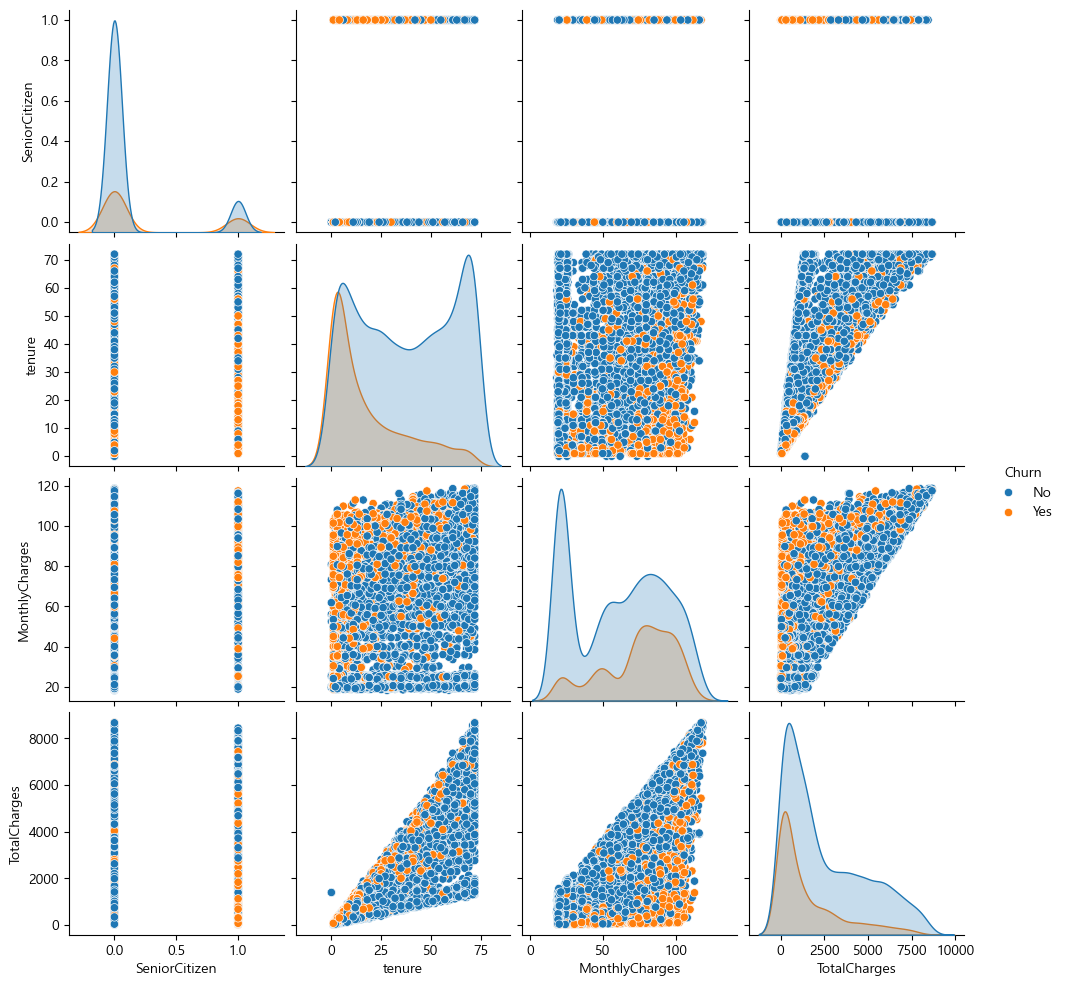

In [96]:
sns.pairplot(telecom_df, hue="Churn")
plt.show()

## 파생변수 생성

In [97]:
telecom_df["FamilySize"] = 1 + (telecom_df["Partner"] == "Yes").astype(int) + (telecom_df["Dependents"] == "Yes").astype(int)
telecom_df["FamilySize"]

0       2
1       1
2       1
3       1
4       1
       ..
7038    3
7039    3
7040    3
7041    2
7042    1
Name: FamilySize, Length: 7043, dtype: int32

In [98]:
service_columns = [
    "PhoneService",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# 총 서비스를 가입한 수
telecom_df["TotalServices"] = (telecom_df[service_columns] == "Yes").sum(axis=1)
telecom_df["Churn"] = (telecom_df["Churn"] == "Yes").astype(int)

In [99]:
telecom_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilySize,TotalServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,2,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,1,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,1,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,1


## 총 서비스별 이탈율

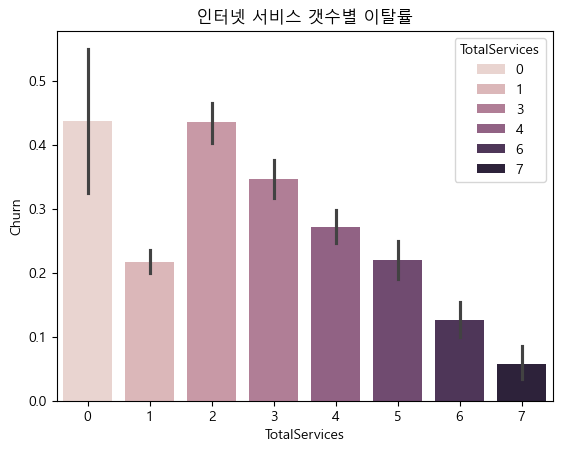

In [100]:
sns.barplot(telecom_df, x="TotalServices", y="Churn", hue="TotalServices")
plt.title("인터넷 서비스 갯수별 이탈률")
plt.show()

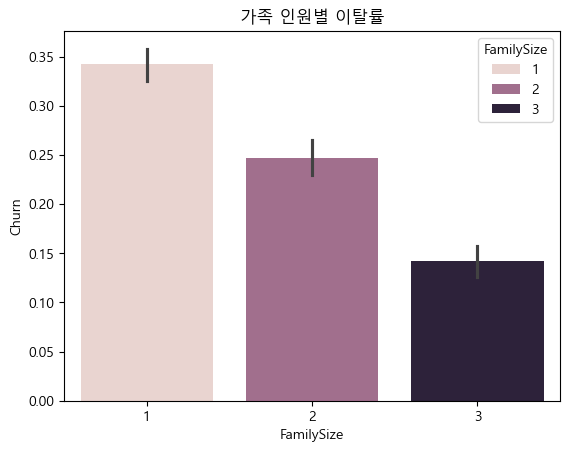

In [101]:
sns.barplot(telecom_df, x="FamilySize", y="Churn", hue="FamilySize")
plt.title("가족 인원별 이탈률")
plt.show()

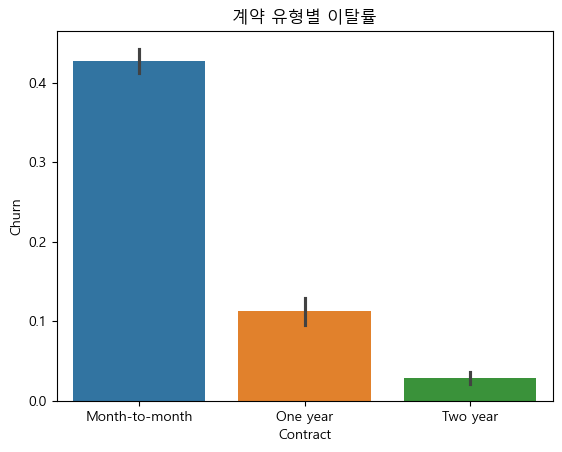

In [102]:
sns.barplot(telecom_df, x="Contract", y="Churn", hue="Contract")
plt.title("계약 유형별 이탈률")
plt.show()

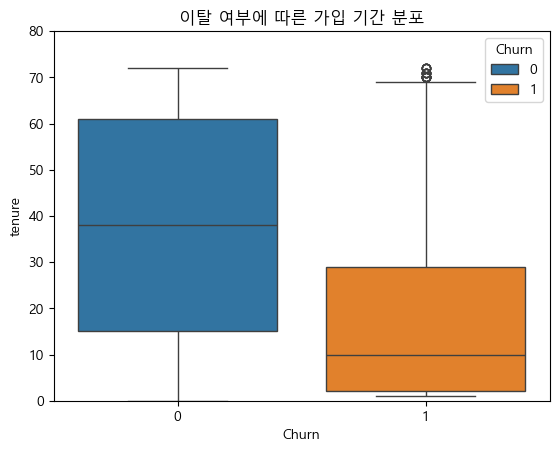

In [103]:
sns.boxplot(telecom_df, x="Churn", y="tenure", hue="Churn")
plt.title("이탈 여부에 따른 가입 기간 분포")
plt.ylim(0, 80)
plt.show()

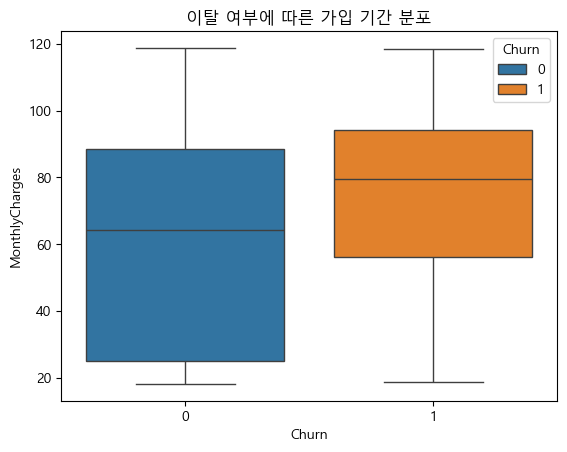

In [104]:
sns.boxplot(telecom_df, x="Churn", y="MonthlyCharges", hue="Churn")
plt.title("이탈 여부에 따른 가입 기간 분포")
plt.show()

In [105]:
X = telecom_df.drop("Churn", axis=1)
y = telecom_df["Churn"]

(5634, 21) (1409, 21) (5634,) (1409,)


In [106]:
for col in X.columns:
    print(f"{col:<20}의 개수: {X[col].nunique()}개")

gender              의 개수: 2개
SeniorCitizen       의 개수: 2개
Partner             의 개수: 2개
Dependents          의 개수: 2개
tenure              의 개수: 73개
PhoneService        의 개수: 2개
MultipleLines       의 개수: 3개
InternetService     의 개수: 3개
OnlineSecurity      의 개수: 3개
OnlineBackup        의 개수: 3개
DeviceProtection    의 개수: 3개
TechSupport         의 개수: 3개
StreamingTV         의 개수: 3개
StreamingMovies     의 개수: 3개
Contract            의 개수: 3개
PaperlessBilling    의 개수: 2개
PaymentMethod       의 개수: 4개
MonthlyCharges      의 개수: 1585개
TotalCharges        의 개수: 6531개
FamilySize          의 개수: 3개
TotalServices       의 개수: 8개


In [111]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   FamilySize                             7043 non-null   int32  
 5   TotalServices                          7043 non-null   int64  
 6   gender_Male                            7043 non-null   int32  
 7   Partner_Yes                            7043 non-null   int32  
 8   Dependents_Yes                         7043 non-null   int32  
 9   PhoneService_Yes                       7043 non-null   int32  
 10  MultipleLines_No phone service         7043 non-null   int32  
 11  Mult

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(5634, 32) (1409, 32) (5634,) (1409,)


## 모델 준비

In [113]:
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=2026)

In [114]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=2026)

In [115]:
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

In [116]:
y_pred

array([0, 0, 0, ..., 0, 1, 0])

In [119]:
rf.score(X_test, y_test) * 100

79.347054648687

In [121]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



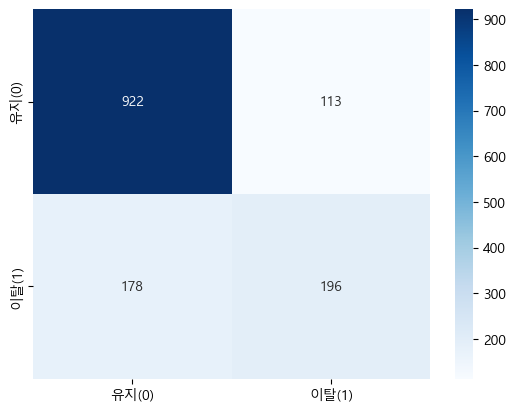

In [135]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, cmap="Blues", annot=True, fmt="d")
plt.xticks([0.5, 1.5], ["유지(0)", "이탈(1)"])
plt.yticks([0.5, 1.5], ["유지(0)", "이탈(1)"])
plt.show()

In [137]:
feature_imp = pd.DataFrame({
    "Features": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_imp.head()

,Features,Importance
3,TotalCharges,0.180574
1,tenure,0.171487
2,MonthlyCharges,0.154503
5,TotalServices,0.040994
12,InternetService_Fiber optic,0.036399


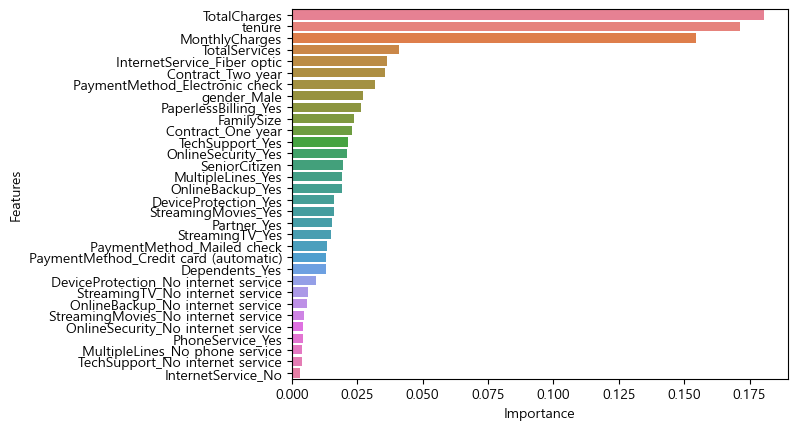

In [139]:
sns.barplot(feature_imp, x="Importance", y="Features", hue="Features")
plt.show()